In [1]:
! pip install numpy
! pip install matplotlib
! pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 60.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 70.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.0/245.0 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 54.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 47.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 78.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 505.5/505.5 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.4/345.4 kB 32.2 MB/s eta 0:00:00


In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
# read science data line by line, parse json, and store in a list
filename = 'batch_20240409_1520_turkPilot.scienceData.jsonl'
data = []

with open(filename) as f:
    for line in f:
        parsed = json.loads(line)
        if parsed['sampleId'] != 'missing':
            data.append(parsed)

len(data)

2

In [9]:
data[0].keys()

dict_keys(['containerTag', 'deliberationId', 'sampleId', 'browserInfo', 'connectionInfo', 'batchId', 'config', 'timeBatchInitialized', 'timeArrived', 'timeEnteredCountdown', 'timeIntroDone', 'timeStarted', 'timeComplete', 'consent', 'introSequence', 'gameId', 'treatment', 'position', 'recordingsFolder', 'recordingRoomName', 'recordingsPath', 'recordingIds', 'surveys', 'prompts', 'qualtrics', 'stageSubmissions', 'QCSurvey', 'exitStatus', 'connectionHistory', 'speakerEvents', 'reports', 'checkIns', 'textChats', 'cumulativeSpeakingTime', 'exportErrors'])

In [30]:
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in data])
submit_times

,submitButton_labeling_1,submitButton_recall_1_1,submitButton_recall_1_2,submitButton_recall_1_4,submitButton_labeling_2,submitButton_recall_2_1,submitButton_recall_2_2,submitButton_recall_2_3,submitButton_recall_2_4,submitButton_labeling_3,...,submitButton_recall_4_3,submitButton_recall_4_4,submitButton_labeling_5,submitButton_recall_5_1,submitButton_recall_5_2,submitButton_recall_5_4,submitButton_recall_1_3,submitButton_recall_3_3,submitButton_recall_3_4,submitButton_recall_5_3
0,451.626,5.223,4.811,4.767,250.266,5.238,4.421,9.260,4.999,382.469,...,5.508,4.261,304.268,4.781,6.954,8.193,6.087,4.767,5.003,4.140
1,452.836,6.458,4.014,1.969,262.485,4.439,3.632,3.468,3.215,387.815,...,2.718,3.495,303.480,2.991,3.148,6.357,3.346,2.987,3.225,2.318


(0.0, 600.0)

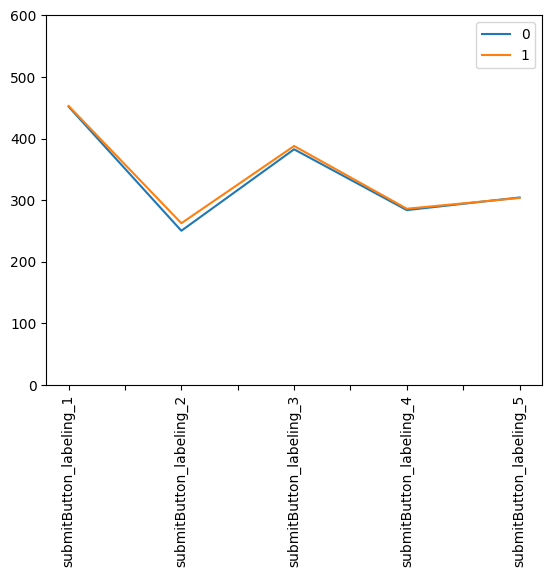

In [31]:
submit_times[[label for label in submit_times.columns if 'labeling' in label]].T.plot()
plt.xticks(rotation=90)
plt.ylim(0, 600)

(0.0, 45.0)

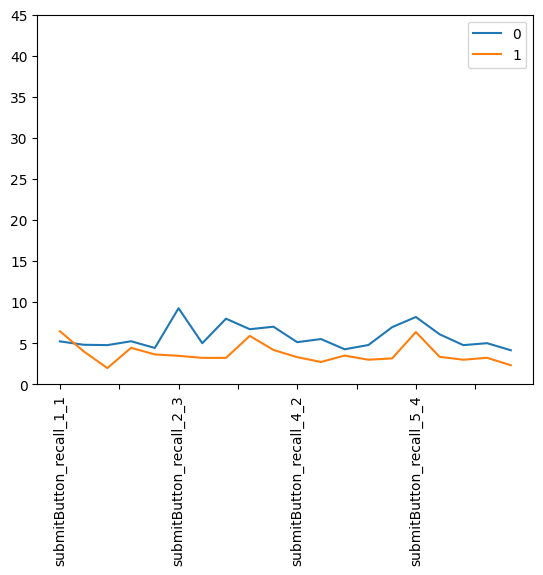

In [33]:
submit_times[[label for label in submit_times.columns if 'labeling' not in label]].T.plot()
plt.xticks(rotation=90)
plt.ylim(0, 45)